<a href="https://colab.research.google.com/github/vodnalasuhas/DAA-CSE-C/blob/main/EXP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

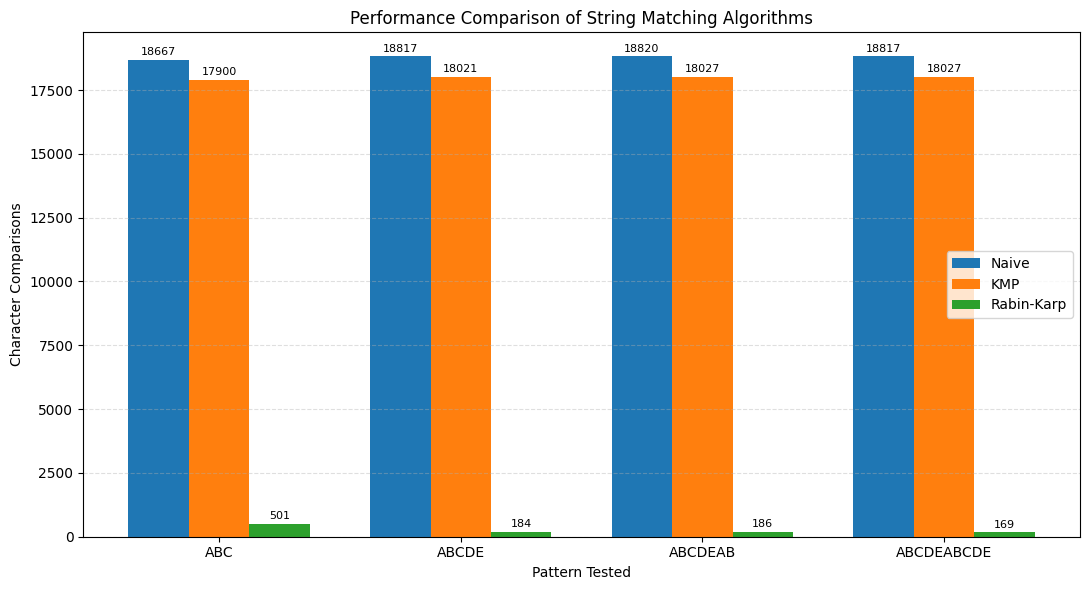

In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Pattern Matching Algorithms --------------------

def naive_search(source, target):
    source_size = len(source)
    target_size = len(target)
    count = 0

    for left in range(source_size - target_size + 1):
        right = 0

        while right < target_size:
            count += 1

            if source[left + right] != target[right]:
                break

            right += 1

    return count


def compute_prefix(pattern):
    prefix = [0] * len(pattern)
    length = 0
    index = 1

    while index < len(pattern):

        if pattern[index] == pattern[length]:
            length += 1
            prefix[index] = length
            index += 1

        elif length > 0:
            length = prefix[length - 1]

        else:
            prefix[index] = 0
            index += 1

    return prefix


def kmp_search(source, target):
    prefix = compute_prefix(target)

    text_index = 0
    pattern_index = 0
    count = 0

    while text_index < len(source):
        count += 1

        if source[text_index] == target[pattern_index]:
            text_index += 1
            pattern_index += 1

            if pattern_index == len(target):
                pattern_index = prefix[pattern_index - 1]

        else:
            if pattern_index != 0:
                pattern_index = prefix[pattern_index - 1]
            else:
                text_index += 1

    return count


def rabin_karp(source, target, mod=101):
    base = 256

    text_length = len(source)
    pattern_length = len(target)

    highest = pow(base, pattern_length - 1, mod)

    hash_pattern = 0
    hash_window = 0
    count = 0

    for i in range(pattern_length):
        hash_pattern = (hash_pattern * base + ord(target[i])) % mod
        hash_window = (hash_window * base + ord(source[i])) % mod

    for start in range(text_length - pattern_length + 1):

        if hash_pattern == hash_window:
            for j in range(pattern_length):
                count += 1

                if source[start + j] != target[j]:
                    break

        if start < text_length - pattern_length:
            hash_window = (
                base * (hash_window - ord(source[start]) * highest)
                + ord(source[start + pattern_length])
            ) % mod

            if hash_window < 0:
                hash_window += mod

    return count


# -------------------- Test Data --------------------

random_text = "".join(random.choice("ABCDE") for _ in range(15000))

patterns = [
    "ABC",
    "ABCDE",
    "ABCDEAB",
    "ABCDEABCDE"
]

results = {
    "Naive": [],
    "KMP": [],
    "Rabin-Karp": []
}

for p in patterns:
    results["Naive"].append(naive_search(random_text, p))
    results["KMP"].append(kmp_search(random_text, p))
    results["Rabin-Karp"].append(rabin_karp(random_text, p))


# -------------------- Plot --------------------

x = np.arange(len(patterns))
width = 0.25

plt.figure(figsize=(11, 6))

plt.bar(x - width, results["Naive"], width, label="Naive")
plt.bar(x, results["KMP"], width, label="KMP")
plt.bar(x + width, results["Rabin-Karp"], width, label="Rabin-Karp")

maximum = max(results["Naive"])

for shift, name in zip([-width, 0, width], results):
    for xpos, value in zip(x + shift, results[name]):
        plt.text(
            xpos,
            value + maximum * 0.01,
            str(value),
            ha="center",
            fontsize=8
        )

plt.xticks(x, patterns)
plt.xlabel("Pattern Tested")
plt.ylabel("Character Comparisons")
plt.title("Performance Comparison of String Matching Algorithms")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()

plt.tight_layout()
plt.show()